In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install -q datasets huggingface_hub jiwer transformers
from huggingface_hub import login
login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import os
import torch
import random
import jiwer
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.optim import AdamW
from tqdm.notebook import tqdm
from torch.amp import autocast, GradScaler
from datasets import load_dataset

# 1. SETUP MÔ HÌNH
MODEL_NAME = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# Thông số mô hình lõi
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
model.config.eos_token_id = processor.tokenizer.sep_token_id

# Thông số sinh chữ
model.generation_config.max_length = 64
model.generation_config.early_stopping = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty = 2.0
model.generation_config.num_beams = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

# 2. DATASET VÀ DATALOADER
hf_dataset = load_dataset("5CD-AI/Viet-Handwriting-OCR-v2", token=True)

class HFTrOCRDataset(Dataset):
    def __init__(self, hf_split, processor, max_target_length=64):
        self.dataset = hf_split
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = item['image'].convert("RGB")
        text_label = item['text']

        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text_label,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True
        ).input_ids

        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        return pixel_values, torch.tensor(labels)

full_dataset = HFTrOCRDataset(hf_dataset['train'], processor)
print(f"Tổng số ảnh trong kho: {len(full_dataset)} ảnh.")

# Chia Train (90%) và Val (10%)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

# 3. VÒNG LẶP HUẤN LUYỆN
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=4e-5)
scaler = GradScaler('cuda')

history_train_loss, history_val_loss = [], []
history_train_acc, history_val_acc = [], []

NUM_EPOCHS = 7
CHECKPOINT_DIR = '/content/drive/MyDrive/OCRProject/TrOCR_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"TRAINING {NUM_EPOCHS} EPOCHS...")

for epoch in range(NUM_EPOCHS):
    # PHASE 1: HỌC TẬP
    model.train()
    epoch_train_loss = 0.0
    loop = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

    for batch_imgs, batch_labels in loop:
        batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(pixel_values=batch_imgs, labels=batch_labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = epoch_train_loss / len(train_dataloader)

    # PHASE 2: VALIDATION
    model.eval()
    epoch_val_loss = 0.0
    val_preds, val_truths = [], []

    MAX_VAL_BATCHES = 20
    current_val_batch = 0


    with torch.no_grad():
        for batch_imgs, batch_labels in val_dataloader:
            if current_val_batch >= MAX_VAL_BATCHES:
                break
            current_val_batch += 1

            batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

            with autocast('cuda'):
                outputs = model(pixel_values=batch_imgs, labels=batch_labels)
                epoch_val_loss += outputs.loss.item()
                generated_ids = model.generate(batch_imgs, num_beams=1, early_stopping=False)

            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)

            labels_eval = batch_labels.clone()
            labels_eval[labels_eval == -100] = processor.tokenizer.pad_token_id
            true_texts = processor.batch_decode(labels_eval, skip_special_tokens=True)

            val_preds.extend(pred_texts)
            val_truths.extend(true_texts)

    avg_val_loss = epoch_val_loss / current_val_batch

    val_cer = jiwer.cer(val_truths, val_preds)
    val_accuracy = max(0, (1 - val_cer) * 100)

    # PHASE 3: ƯỚC TÍNH TRAIN ACCURACY
    sample_imgs, sample_labels = next(iter(train_dataloader))
    with torch.no_grad():
        with autocast('cuda'):
            gen_ids = model.generate(sample_imgs.to(device))

        train_preds = processor.batch_decode(gen_ids, skip_special_tokens=True)
        lbls = sample_labels.clone()
        lbls[lbls == -100] = processor.tokenizer.pad_token_id
        train_truths = processor.batch_decode(lbls, skip_special_tokens=True)

    train_cer = jiwer.cer(train_truths, train_preds)
    train_accuracy = max(0, (1 - train_cer) * 100)

    # Lưu lại lịch sử
    history_train_loss.append(avg_train_loss)
    history_val_loss.append(avg_val_loss)
    history_train_acc.append(train_accuracy)
    history_val_acc.append(val_accuracy)

    print(f"TỔNG KẾT EPOCH {epoch+1}:")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.1f}%")
    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.1f}%")

    # Lưu Checkpoint
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"trocr_epoch_{epoch+1}.pth")
    model.save_pretrained(checkpoint_path)
    processor.save_pretrained(checkpoint_path)

# 4. VẼ BIỂU ĐỒ
epochs_list = list(range(1, NUM_EPOCHS + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epochs_list, history_train_loss, marker='o', linestyle='-', color='blue', linewidth=2, label='Train Loss')
ax1.plot(epochs_list, history_val_loss, marker='s', linestyle='--', color='red', linewidth=2, label='Validation Loss')
ax1.set_title('Biểu đồ Lỗi (Cross Entropy Loss)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs_list)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

ax2.plot(epochs_list, history_train_acc, marker='o', linestyle='-', color='green', linewidth=2, label='Train Accuracy')
ax2.plot(epochs_list, history_val_acc, marker='s', linestyle='--', color='orange', linewidth=2, label='Validation Accuracy')
ax2.set_title('Biểu đồ Độ Chính Xác (Accuracy)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_xticks(epochs_list)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

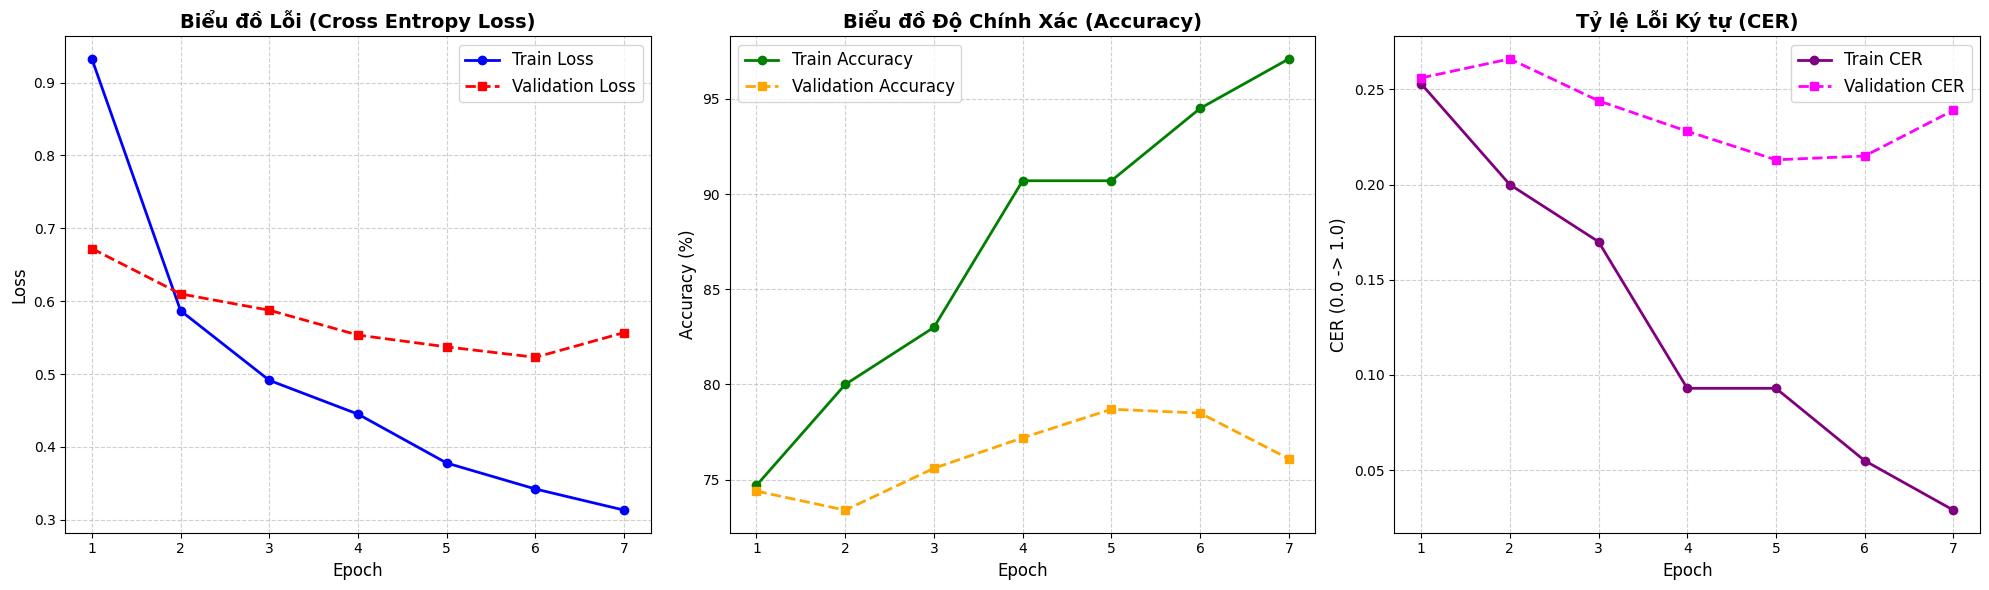

In [ ]:
import matplotlib.pyplot as plt

history_train_loss = [0.9324, 0.5869, 0.4914, 0.4450, 0.3779, 0.3423, 0.3133]
history_val_loss =   [0.6722, 0.6100, 0.5876, 0.5535, 0.5373, 0.5230, 0.5570]
history_train_acc =  [74.7, 80.0, 83.0, 90.7, 90.7, 94.5, 97.1]
history_val_acc =    [74.4, 73.4, 75.6, 77.2, 78.7, 78.5, 76.1]

history_train_cer = [1 - (acc / 100) for acc in history_train_acc]
history_val_cer =   [1 - (acc / 100) for acc in history_val_acc]

epochs_list = list(range(1, len(history_train_loss) + 1))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.plot(epochs_list, history_train_loss, marker='o', linestyle='-', color='blue', linewidth=2, label='Train Loss')
ax1.plot(epochs_list, history_val_loss, marker='s', linestyle='--', color='red', linewidth=2, label='Validation Loss')
ax1.set_title('Biểu đồ Lỗi (Cross Entropy Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs_list)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

ax2.plot(epochs_list, history_train_acc, marker='o', linestyle='-', color='green', linewidth=2, label='Train Accuracy')
ax2.plot(epochs_list, history_val_acc, marker='s', linestyle='--', color='orange', linewidth=2, label='Validation Accuracy')
ax2.set_title('Biểu đồ Độ Chính Xác (Accuracy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_xticks(epochs_list)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)

ax3.plot(epochs_list, history_train_cer, marker='o', linestyle='-', color='purple', linewidth=2, label='Train CER')
ax3.plot(epochs_list, history_val_cer, marker='s', linestyle='--', color='magenta', linewidth=2, label='Validation CER')
ax3.set_title('Tỷ lệ Lỗi Ký tự (CER)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('CER (0.0 -> 1.0)', fontsize=12)
ax3.set_xticks(epochs_list)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(fontsize=12)

plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/480 [00:01<?, ?it/s]

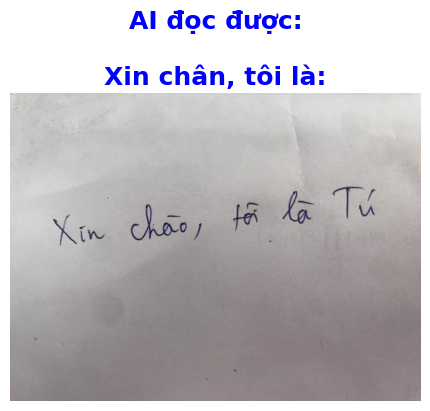

In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

CHECKPOINT_PATH = '/content/drive/MyDrive/OCRProject/TrOCR_Checkpoints/trocr_epoch_7.pth'

IMAGE_PATH = '/content/IMG_2383.jpg'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

processor = TrOCRProcessor.from_pretrained(CHECKPOINT_PATH)
model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_PATH).to(device)

model.generation_config.num_beams = 4
model.generation_config.max_length = 64
model.generation_config.early_stopping = True

image = Image.open(IMAGE_PATH).convert("RGB")

pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

with torch.no_grad():
    generated_ids = model.generate(pixel_values)

predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

plt.figure(figsize=(10, 4))
plt.imshow(image)
plt.axis('off') # Ẩn trục tọa độ đi cho đẹp
plt.title(f"AI đọc được:\n\n{predicted_text}", fontsize=18, color='blue', fontweight='bold')
plt.show()
